In [1]:
from arcgis.gis import GIS
from IPython.display import display
gis = GIS("https://deldev.maps.arcgis.com", "deldev", "P@ssw0rd@123")

In [2]:
gis.content.is_service_name_available('data2', 'Feature Service')

True

In [3]:
fgdb = gis.content.get('f81df80cbf82459287d47c57dbc8efc9')

In [4]:
fgdb

<Item title:"test_fgdb.gdb" type:Feature Service owner:demo_deldev>

In [5]:
fgdb.layers

[<FeatureLayer url:"http://services6.arcgis.com/SMX5BErCXLM7eDtY/arcgis/rest/services/t3_Name_of_service/FeatureServer/0">,
 <FeatureLayer url:"http://services6.arcgis.com/SMX5BErCXLM7eDtY/arcgis/rest/services/t3_Name_of_service/FeatureServer/1">,
 <FeatureLayer url:"http://services6.arcgis.com/SMX5BErCXLM7eDtY/arcgis/rest/services/t3_Name_of_service/FeatureServer/2">]

In [6]:
for layer in fgdb.layers:
    print(layer.query())
    print(layer.properties.name)

[{'attributes': {'Shape_Leng': 11.9562211972, 'OBJECTID_1': 1, 'POP1990': 1108229, 'STATE_FIPS': '15', 'Shape_Area': 1.42887521535158, 'STATE_NAME': 'Hawaii-EDITED', 'Shape_Length': 11.9563215283615, 'SUB_REGION': 'Pacific', 'POP2000': 1184688, 'POP90_SQMI': 174, 'STATE_ABBR': 'HI', 'OBJECTID': 1, 'AREA': 6380.614}, 'geometry': {'rings': [[[-17737115.4904887, 2505341.93350041], [-17748733.9183591, 2495697.18269983], [-17763919.4072675, 2497637.41315148], [-17771067.1183084, 2505341.93382513], [-17781788.6849586, 2507261.28118799], [-17788943.1903897, 2515930.34006331], [-17779118.4846978, 2529437.38236234], [-17763919.4069155, 2537156.33973418], [-17743359.5458289, 2539057.27082442], [-17738005.5569186, 2535204.25467282], [-17732637.979243, 2526525.34499474], [-17736211.8348892, 2516890.58312876], [-17737115.4904887, 2505341.93350041]], [[-17819334.5514161, 2512016.62605913], [-17816650.762571, 2510118.72538361], [-17821114.6848896, 2501430.65039131], [-17830056.1182189, 2495645.935138

In [7]:
states = fgdb.layers[0]

In [8]:
states.properties.capabilities

'Create,Delete,Query,Update,Editing'

In [9]:
from pandas.io.json import json_normalize

In [10]:
json_normalize(states.query('OBJECTID=1'))

,attributes.AREA,attributes.OBJECTID,attributes.OBJECTID_1,attributes.POP1990,attributes.POP2000,attributes.POP90_SQMI,attributes.STATE_ABBR,attributes.STATE_FIPS,attributes.STATE_NAME,attributes.SUB_REGION,attributes.Shape_Area,attributes.Shape_Leng,attributes.Shape_Length,geometry.rings
0,6380.614,1,1,1108229,1184688,174,HI,15,Hawaii-EDITED,Pacific,1.428875,11.956221,11.956322,"[[[-17737115.4904887, 2505341.93350041], [-177..."


In [11]:
states.query('OBJECTID=1', as_obj=True)

{
  "fields": [
    {
      "alias": "OBJECTID_1",
      "defaultValue": null,
      "name": "OBJECTID_1",
      "sqlType": "sqlTypeOther",
      "type": "esriFieldTypeInteger",
      "domain": null
    },
    {
      "alias": "OBJECTID",
      "defaultValue": null,
      "name": "OBJECTID",
      "sqlType": "sqlTypeOther",
      "type": "esriFieldTypeInteger",
      "domain": null
    },
    {
      "alias": "AREA",
      "defaultValue": null,
      "name": "AREA",
      "sqlType": "sqlTypeOther",
      "type": "esriFieldTypeDouble",
      "domain": null
    },
    {
      "alias": "STATE_NAME",
      "length": 25,
      "defaultValue": null,
      "name": "STATE_NAME",
      "sqlType": "sqlTypeOther",
      "type": "esriFieldTypeString",
      "domain": null
    },
    {
      "alias": "STATE_FIPS",
      "length": 2,
      "defaultValue": null,
      "name": "STATE_FIPS",
      "sqlType": "sqlTypeOther",
      "type": "esriFieldTypeString",
      "domain": null
    },
    {
      "a

In [12]:
states.query('OBJECTID=1', returnDistinctValues=True, as_dict=True)

{'features': [{'attributes': {'AREA': 6380.614,
    'OBJECTID': 1,
    'OBJECTID_1': 1,
    'POP1990': 1108229,
    'POP2000': 1184688,
    'POP90_SQMI': 174,
    'STATE_ABBR': 'HI',
    'STATE_FIPS': '15',
    'STATE_NAME': 'Hawaii-EDITED',
    'SUB_REGION': 'Pacific',
    'Shape_Area': 1.42887521535158,
    'Shape_Leng': 11.9562211972,
    'Shape_Length': 11.9563215283615},
   'geometry': {'rings': [[[-17737115.4904887, 2505341.93350041],
      [-17748733.9183591, 2495697.18269983],
      [-17763919.4072675, 2497637.41315148],
      [-17771067.1183084, 2505341.93382513],
      [-17781788.6849586, 2507261.28118799],
      [-17788943.1903897, 2515930.34006331],
      [-17779118.4846978, 2529437.38236234],
      [-17763919.4069155, 2537156.33973418],
      [-17743359.5458289, 2539057.27082442],
      [-17738005.5569186, 2535204.25467282],
      [-17732637.979243, 2526525.34499474],
      [-17736211.8348892, 2516890.58312876],
      [-17737115.4904887, 2505341.93350041]],
     [[-1781933

In [13]:
states.properties

{
  "fields": [
    {
      "alias": "OBJECTID_1",
      "editable": false,
      "defaultValue": null,
      "name": "OBJECTID_1",
      "sqlType": "sqlTypeOther",
      "type": "esriFieldTypeInteger",
      "nullable": false,
      "domain": null
    },
    {
      "alias": "OBJECTID",
      "editable": true,
      "defaultValue": null,
      "name": "OBJECTID",
      "sqlType": "sqlTypeOther",
      "type": "esriFieldTypeInteger",
      "nullable": true,
      "domain": null
    },
    {
      "alias": "AREA",
      "editable": true,
      "defaultValue": null,
      "name": "AREA",
      "sqlType": "sqlTypeOther",
      "type": "esriFieldTypeDouble",
      "nullable": true,
      "domain": null
    },
    {
      "alias": "STATE_NAME",
      "editable": true,
      "length": 25,
      "defaultValue": null,
      "name": "STATE_NAME",
      "sqlType": "sqlTypeOther",
      "type": "esriFieldTypeString",
      "nullable": true,
      "domain": null
    },
    {
      "alias": "STATE_

In [14]:
res = states.query('OBJECTID=1', as_dict=True)
res['features'][0]['attributes']

{'AREA': 6380.614,
 'OBJECTID': 1,
 'OBJECTID_1': 1,
 'POP1990': 1108229,
 'POP2000': 1184688,
 'POP90_SQMI': 174,
 'STATE_ABBR': 'HI',
 'STATE_FIPS': '15',
 'STATE_NAME': 'Hawaii-EDITED',
 'SUB_REGION': 'Pacific',
 'Shape_Area': 1.42887521535158,
 'Shape_Leng': 11.9562211972,
 'Shape_Length': 11.9563215283615}

In [15]:
res = states.query('OBJECTID=1', as_obj=True)

In [16]:
f0 = res.features[0]

In [17]:
f0.attributes.STATE_NAME

'Hawaii-EDITED'

In [18]:
f0.attributes.POP1990

1108229

In [19]:
f0['attributes']['STATE_NAME']='H333'
f0.attributes.STATE_NAME

'H333'

In [20]:
f0.attributes.STATE_NAME = 'Hawaii-EDITED'
f0.attributes.STATE_NAME

'Hawaii-EDITED'

In [21]:
states.edit_features(updates=[f0])

{'addResults': [],
 'deleteResults': [],
 'updateResults': [{'globalId': None, 'objectId': 1, 'success': True}]}

In [22]:
states.query('OBJECTID=1')

[{'attributes': {'AREA': 6380.614,
   'OBJECTID': 1,
   'OBJECTID_1': 1,
   'POP1990': 1108229,
   'POP2000': 1184688,
   'POP90_SQMI': 174,
   'STATE_ABBR': 'HI',
   'STATE_FIPS': '15',
   'STATE_NAME': 'Hawaii-EDITED',
   'SUB_REGION': 'Pacific',
   'Shape_Area': 1.42887521535158,
   'Shape_Leng': 11.9562211972,
   'Shape_Length': 11.9563215283615},
  'geometry': {'rings': [[[-17737115.4904887, 2505341.93350041],
     [-17748733.9183591, 2495697.18269983],
     [-17763919.4072675, 2497637.41315148],
     [-17771067.1183084, 2505341.93382513],
     [-17781788.6849586, 2507261.28118799],
     [-17788943.1903897, 2515930.34006331],
     [-17779118.4846978, 2529437.38236234],
     [-17763919.4069155, 2537156.33973418],
     [-17743359.5458289, 2539057.27082442],
     [-17738005.5569186, 2535204.25467282],
     [-17732637.979243, 2526525.34499474],
     [-17736211.8348892, 2516890.58312876],
     [-17737115.4904887, 2505341.93350041]],
    [[-17819334.5514161, 2512016.62605913],
     [-17

In [23]:
crs = gis.content.search('Chennai Rainfall')
crs

[<Item title:"chennai-rainfall" type:CSV owner:demo_deldev>,
 <Item title:"chennai-rainfall" type:Feature Service owner:demo_deldev>]

In [24]:
cr = crs[1]

In [25]:
cr

<Item title:"chennai-rainfall" type:Feature Service owner:demo_deldev>

In [26]:
cr.layers

[<FeatureLayer url:"http://services6.arcgis.com/SMX5BErCXLM7eDtY/arcgis/rest/services/chennai_rainfall/FeatureServer/0">]

In [27]:
lyr = cr.layers[0]

In [29]:
lyr.attachments.add(1, 'C:\\Users\\rohit\\AppData\\Local\\Temp\\AppTemplate.png')

{'addAttachmentResult': {'globalId': None, 'objectId': 2, 'success': True}}

In [30]:
lyr.attachments.get_list(1)

[{'contentType': 'image/png',
  'id': 1,
  'name': 'AppTemplate.png',
  'parentObjectId': 1,
  'size': 1394},
 {'contentType': 'image/png',
  'id': 2,
  'name': 'AppTemplate.png',
  'parentObjectId': 1,
  'size': 1394}]

In [31]:
lyr.attachments.download(1, 1)

'C:\\Users\\rohit\\AppData\\Local\\Temp\\AppTemplate.png'

In [32]:
lyr.attachments.get_list(2)

[]

In [33]:
lyr.attachments.delete(1,3)

{'deleteAttachmentResults': [{'error': {'code': 1010,
    'description': 'The specified attachment could not be deleted or does not exist.'},
   'globalId': None,
   'objectId': 3,
   'success': False}]}

In [34]:
lyr.query('FID=1', returnIDsOnly=True)

{'objectIdFieldName': 'FID', 'objectIds': [1]}

In [35]:
lyr.properties.htmlPopupType

'esriServerHTMLPopupTypeNone'

In [36]:
chennaipop = gis.content.search("Chennai Population", "feature service", outside_org=True)[0]

In [37]:
chennaipop.layers

[<FeatureLayer url:"http://services.arcgis.com/jIL9msH9OI208GCb/arcgis/rest/services/Enriched Chennai_Demographics/FeatureServer/0">]

In [38]:
l = chennaipop.layers[0]

In [39]:
l

<FeatureLayer url:"http://services.arcgis.com/jIL9msH9OI208GCb/arcgis/rest/services/Enriched Chennai_Demographics/FeatureServer/0">

In [40]:
l.properties.hasAttachments

False

In [41]:
dict(l.properties)

{'advancedQueryCapabilities': {'supportsAdvancedQueryRelated': True,
  'supportsDistinct': True,
  'supportsOrderBy': True,
  'supportsPagination': True,
  'supportsQueryRelatedPagination': True,
  'supportsQueryWithDistance': True,
  'supportsQueryWithResultType': True,
  'supportsReturningGeometryCentroid': True,
  'supportsReturningQueryExtent': True,
  'supportsSqlExpression': True,
  'supportsStatistics': True},
 'allowGeometryUpdates': True,
 'capabilities': 'Query',
 'copyrightText': '',
 'currentVersion': 10.41,
 'defaultVisibility': True,
 'description': '',
 'displayField': '',
 'drawingInfo': {'renderer': {'authoringInfo': {'visualVariables': [{'maxSliderValue': 4794844,
      'minSliderValue': 24411,
      'theme': 'high-to-low',
      'type': 'colorInfo'}]},
   'classBreakInfos': [{'classMaxValue': 9007199254740991,
     'symbol': {'color': [170, 170, 170, 255],
      'outline': {'color': [214, 214, 214, 80],
       'style': 'esriSLSSolid',
       'type': 'esriSLS',
      

In [42]:
chennailakes = gis.content.search("Chennai Lakes", "feature collection", outside_org=True)[0]

In [43]:
chennailakes.layers

[<FeatureCollection>]

In [44]:
lyr = chennailakes.layers[0]

In [45]:
lyr.properties

{
  "nextObjectId": 11,
  "layerDefinition": {
    "types": [],
    "displayField": "TITLE",
    "templates": [],
    "drawingInfo": {
      "renderer": {
        "symbol": {
          "url": "http://static.arcgis.com/images/Symbols/Basic/GreenStickpin.png",
          "width": 24,
          "height": 24,
          "yoffset": 12,
          "contentType": "image/png",
          "type": "esriPMS",
          "angle": 0,
          "xoffset": 0
        },
        "type": "simple",
        "description": "",
        "label": "Stickpin"
      }
    },
    "type": "Feature Layer",
    "objectIdField": "OBJECTID",
    "capabilities": "Query,Extract",
    "hasAttachments": false,
    "extent": {
      "xmin": 8892549.347681843,
      "ymin": 1448991.9567190532,
      "ymax": 1485375.9823827483,
      "type": "extent",
      "spatialReference": {
        "latestWkid": 3857,
        "wkid": 102100
      },
      "xmax": 8930691.424996095
    },
    "typeIdField": "",
    "visibilityField": "VISIBLE

<Item title:"Chennai Lakes" type:Feature Collection owner:geonuma>
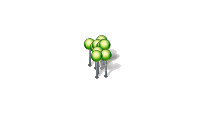

In [46]:
chennailakes

In [47]:
chennailakes.get_data()

{'layers': [{'featureSet': {'features': [{'attributes': {'OBJECTID': 0,
       'VISIBLE': 1,
       'description': 'blayer desc',
       'title': 'blayer'},
      'geometry': {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
       'x': 8892549.347781843,
       'y': 1479719.6421896527},
      'symbol': {'angle': 0,
       'contentType': 'image/png',
       'height': 24,
       'type': 'esriPMS',
       'url': 'http://static.arcgis.com/images/Symbols/Basic/GreenStickpin.png',
       'width': 24,
       'xoffset': 0,
       'yoffset': 9}},
     {'attributes': {'OBJECTID': 1,
       'VISIBLE': 1,
       'description': 'blayer desc',
       'title': 'blayer'},
      'geometry': {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
       'x': 8921442.544473602,
       'y': 1485375.9822827482},
      'symbol': {'angle': 0,
       'contentType': 'image/png',
       'height': 24,
       'type': 'esriPMS',
       'url': 'http://static.arcgis.com/images/Symbols/Basic/GreenStickpi

In [48]:
sdnasvc = NetworkService('https://sampleserver6.arcgisonline.com/arcgis/rest/services/NetworkAnalysis/SanDiego/NAServer')

In [49]:
sdnasvc.route_layers

[<RouteNetworkLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/NetworkAnalysis/SanDiego/NAServer/Route">]

In [50]:
sdnasvc.closest_facility_layers

[<ClosestFacilityNetworkLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/NetworkAnalysis/SanDiego/NAServer/ClosestFacility">]

In [51]:
sdnasvc.service_area_layers

[<ServiceAreaNetworkLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/NetworkAnalysis/SanDiego/NAServer/ServiceArea">]

In [52]:
sdroute = sdnasvc.route_layers[0]

In [53]:
tm = PropertyMap(sdroute.retrieve_travel_modes())

In [54]:
for mode in tm.supportedTravelModes:
    print(mode.name)

Driving Time
Driving Distance
Trucking Time
Trucking Distance
Walking Time
Walking Distance
Rural Driving Time
Rural Driving Distance


In [55]:
for mode in sdroute.properties.supportedTravelModes:
    print(mode.name)

Driving Time
Driving Distance
Trucking Time
Trucking Distance
Walking Time
Walking Distance
Rural Driving Time
Rural Driving Distance


In [56]:
sdroute

<RouteNetworkLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/NetworkAnalysis/SanDiego/NAServer/Route">

In [58]:
vectile = gis.content.get('dcbbba0edf094eaa81af19298b9c6247')

<Item title:"World Navigation Map" type:Vector Tile Service owner:esri_vector>
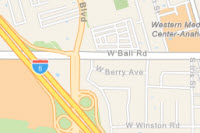

In [59]:
vectile

In [60]:
vectile.type

'Vector Tile Service'

In [61]:
vectile.access

'public'

In [62]:
vectile.url

'http://basemaps.arcgis.com/b2/arcgis/rest/services/World_Basemap/VectorTileServer'

In [63]:
vectile.layers

[<VectorTileLayer url:"http://basemaps.arcgis.com/b2/arcgis/rest/services/World_Basemap/VectorTileServer">]

In [64]:
lyr = vectile.layers[0]

In [65]:
lyr.properties

{
  "exportTilesAllowed": false,
  "tileInfo": {
    "lods": [
      {
        "level": 0,
        "resolution": 78271.51696399994,
        "scale": 295828763.795777
      },
      {
        "level": 1,
        "resolution": 39135.75848200009,
        "scale": 147914381.897889
      },
      {
        "level": 2,
        "resolution": 19567.87924099992,
        "scale": 73957190.948944
      },
      {
        "level": 3,
        "resolution": 9783.93962049996,
        "scale": 36978595.474472
      },
      {
        "level": 4,
        "resolution": 4891.96981024998,
        "scale": 18489297.737236
      },
      {
        "level": 5,
        "resolution": 2445.98490512499,
        "scale": 9244648.868618
      },
      {
        "level": 6,
        "resolution": 1222.992452562495,
        "scale": 4622324.434309
      },
      {
        "level": 7,
        "resolution": 611.4962262813797,
        "scale": 2311162.217155
      },
      {
        "level": 8,
        "resolution": 305

In [66]:
lyr.info

{'resourceInfo': ['../fonts/Arial Regular/0-255.pbf',
  '../fonts/Arial Regular/256-511.pbf',
  '../fonts/Arial Regular/512-767.pbf',
  '../fonts/Arial Regular/768-1023.pbf',
  '../fonts/Arial Regular/1024-1279.pbf',
  '../fonts/Arial Regular/1280-1535.pbf',
  '../fonts/Arial Regular/1536-1791.pbf',
  '../fonts/Arial Regular/1792-2047.pbf',
  '../fonts/Arial Regular/2048-2303.pbf',
  '../fonts/Arial Regular/2304-2559.pbf',
  '../fonts/Arial Regular/2560-2815.pbf',
  '../fonts/Arial Regular/2816-3071.pbf',
  '../fonts/Arial Regular/3072-3327.pbf',
  '../fonts/Arial Regular/3328-3583.pbf',
  '../fonts/Arial Regular/3584-3839.pbf',
  '../fonts/Arial Regular/3840-4095.pbf',
  '../fonts/Arial Regular/4096-4351.pbf',
  '../fonts/Arial Regular/4352-4607.pbf',
  '../fonts/Arial Regular/4608-4863.pbf',
  '../fonts/Arial Regular/4864-5119.pbf',
  '../fonts/Arial Regular/5120-5375.pbf',
  '../fonts/Arial Regular/5376-5631.pbf',
  '../fonts/Arial Regular/5632-5887.pbf',
  '../fonts/Arial Regular/5

In [68]:
gis.content.search('USA', outside_org=True)

[<Item title:"World Boundaries and Places" type:Map Service owner:esri>,
 <Item title:"World Imagery" type:Map Service owner:esri>,
 <Item title:"USA Topo Maps" type:Map Service owner:esri>,
 <Item title:"2012 USA Tapestry Segmentation (Mature Support)" type:Map Service owner:esri>,
 <Item title:"Bing Maps Hybrid" type:Web Map owner:esri_en>,
 <Item title:"Bing Maps Aerial" type:Web Map owner:esri_en>,
 <Item title:"USA Counties" type:Feature Service owner:esri_dm>,
 <Item title:"2012 USA Median Household Income (Mature Support)" type:Map Service owner:esri>,
 <Item title:"USA States (Generalized)" type:Feature Service owner:esri>,
 <Item title:"2012 USA Population Density (Mature Support)" type:Map Service owner:esri>]

In [69]:
bing = gis.content.search('USA', outside_org=True)[3]

<Item title:"2012 USA Tapestry Segmentation (Mature Support)" type:Map Service owner:esri>
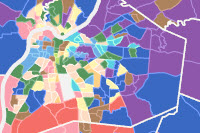

In [70]:
bing

In [71]:
'layers' in bing

True

In [72]:
chennaipop = gis.content.search("Chennai Population", "feature service", outside_org=True)[0]

In [73]:
chennaipop.layers

In [74]:
fl = chennaipop.layers[0]

In [75]:
fl.url

'http://services.arcgis.com/jIL9msH9OI208GCb/arcgis/rest/services/Enriched Chennai_Demographics/FeatureServer/0'

In [76]:
chennaipop.url

'http://services.arcgis.com/jIL9msH9OI208GCb/arcgis/rest/services/Enriched Chennai_Demographics/FeatureServer'

In [77]:
for lyr in chennaipop.layers:
    print(lyr.properties.type)
    print(lyr.properties.name)
    print(lyr.url)
    

Feature Layer
Enriched Chennai_Demographics
http://services.arcgis.com/jIL9msH9OI208GCb/arcgis/rest/services/Enriched Chennai_Demographics/FeatureServer/0


In [78]:
map = gis.map('Tamil Nadu', 6)
map

In [79]:
map.add_layer(chennaipop)

In [80]:
ls_water = gis.content.search("Land Water Boundary (453) 1990-2010", max_items=1, outside_org=True)[0]
#ls_water

In [81]:
ls_water.layers

[<ImageLayer url:"http://imagery.arcgisonline.com/ArcGIS/rest/services/LandsatGLS/LandWater/ImageServer">]

In [82]:
map.add_layer(ls_water)

In [83]:
imglyr = ls_water.layers[0]

In [84]:
imglyr.properties.rasterTypeInfos

[{
   "help": "",
   "name": "Raster Dataset",
   "description": "Supports all ArcGIS Raster Datasets"
 }]

In [85]:
lyr = chennaipop.layers[0]

In [86]:
lyr.properties.extent.xmax

8944863.6153

In [87]:
lyr.query()

[{'attributes': {'AVGHHSZ_CY': 4.17,
   'Age_15_30': 88422,
   'Age_30_45': 68297,
   'Age_45_60': 47200,
   'ENRICH_FID': 1,
   'FEMALES_CY': 152876,
   'HasData': 1,
   'ID': '33050001',
   'ID_1': '0',
   'MALES_CY': 151502,
   'NAME': 'Arani',
   'OBJECTID': 1,
   'POPPRM_CY': 0.244,
   'PPPC_CY': 70473.05,
   'TOTHH_CY': 72919,
   'TOTPOP_60P': 33083,
   'TOTPOP_CY': 304378,
   'TOTPOP_U15': 78115,
   'sourceCountry': 'IN'},
  'geometry': {'rings': [[[8827199.1362, 1430635.7809],
     [8827377.3587, 1430605.8785],
     [8827631.2784, 1430639.2049],
     [8827901.7848, 1430732.3364],
     [8828174.2949, 1430786.3209],
     [8828349.7344, 1430815.3105],
     [8828487.8819, 1430802.9842],
     [8828594.4147, 1430631.4439],
     [8828676.5685, 1430557.0302],
     [8828974.3481, 1430494.144],
     [8829229.1584, 1430507.7256],
     [8829445.6748, 1430499.5081],
     [8829707.053, 1430375.5621],
     [8830492.3007, 1429984.0969],
     [8831175.691, 1429665.9069],
     [8831737.7431, 142

In [88]:
lyr.properties

{
  "fields": [
    {
      "alias": "",
      "actualType": "int",
      "editable": false,
      "defaultValue": null,
      "name": "OBJECTID",
      "sqlType": "sqlTypeInteger",
      "type": "esriFieldTypeInteger",
      "nullable": false,
      "domain": null
    },
    {
      "alias": "ID",
      "actualType": "nvarchar",
      "editable": true,
      "length": 50,
      "defaultValue": null,
      "name": "ID",
      "sqlType": "sqlTypeNVarchar",
      "type": "esriFieldTypeString",
      "nullable": true,
      "domain": null
    },
    {
      "alias": "NAME",
      "actualType": "nvarchar",
      "editable": true,
      "length": 70,
      "defaultValue": null,
      "name": "NAME",
      "sqlType": "sqlTypeNVarchar",
      "type": "esriFieldTypeString",
      "nullable": true,
      "domain": null
    },
    {
      "alias": "2013 Total Population (MBR)",
      "actualType": "int",
      "editable": true,
      "defaultValue": null,
      "name": "TOTPOP_CY",
      "sqlTyp

<Item title:"Chennai Population" type:Feature Service owner:lisa_berry>
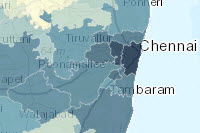

In [89]:
chennaipop

In [90]:
chennaipop.url

'http://services.arcgis.com/jIL9msH9OI208GCb/arcgis/rest/services/Enriched Chennai_Demographics/FeatureServer'

In [91]:
l = chennaipop.layers[0]

In [92]:
l

<FeatureLayer url:"http://services.arcgis.com/jIL9msH9OI208GCb/arcgis/rest/services/Enriched Chennai_Demographics/FeatureServer/0">

In [93]:
l.properties.name

'Enriched Chennai_Demographics'

In [94]:
l.properties.fields

[{
   "defaultValue": null,
   "actualType": "int",
   "editable": false,
   "domain": null,
   "type": "esriFieldTypeInteger",
   "nullable": false,
   "alias": "",
   "name": "OBJECTID",
   "sqlType": "sqlTypeInteger"
 }, {
   "defaultValue": null,
   "actualType": "nvarchar",
   "length": 50,
   "editable": true,
   "domain": null,
   "type": "esriFieldTypeString",
   "nullable": true,
   "alias": "ID",
   "name": "ID",
   "sqlType": "sqlTypeNVarchar"
 }, {
   "defaultValue": null,
   "actualType": "nvarchar",
   "length": 70,
   "editable": true,
   "domain": null,
   "type": "esriFieldTypeString",
   "nullable": true,
   "alias": "NAME",
   "name": "NAME",
   "sqlType": "sqlTypeNVarchar"
 }, {
   "defaultValue": null,
   "actualType": "int",
   "editable": true,
   "domain": null,
   "type": "esriFieldTypeInteger",
   "nullable": true,
   "alias": "2013 Total Population (MBR)",
   "name": "TOTPOP_CY",
   "sqlType": "sqlTypeInteger"
 }, {
   "defaultValue": null,
   "actualType": "

In [95]:
l.properties.advancedQueryCapabilities

{
  "supportsStatistics": true,
  "supportsDistinct": true,
  "supportsOrderBy": true,
  "supportsSqlExpression": true,
  "supportsQueryWithResultType": true,
  "supportsReturningGeometryCentroid": true,
  "supportsAdvancedQueryRelated": true,
  "supportsPagination": true,
  "supportsQueryWithDistance": true,
  "supportsReturningQueryExtent": true,
  "supportsQueryRelatedPagination": true
}

In [96]:
l.properties.copyrightText

''

In [97]:
l.properties.geometryType

'esriGeometryPolygon'

In [98]:
l.properties.advancedQueryCapabilities.supportsOrderBy

True

In [99]:
l.properties.advancedQueryCapabilities.supportsStatistics

True

In [100]:
l.properties['geometryType']

'esriGeometryPolygon'

In [101]:
l.properties['advancedQueryCapabilities']['supportsOrderBy']

True

In [102]:
l.properties.advancedQueryCapabilities

{
  "supportsStatistics": true,
  "supportsDistinct": true,
  "supportsOrderBy": true,
  "supportsSqlExpression": true,
  "supportsQueryWithResultType": true,
  "supportsReturningGeometryCentroid": true,
  "supportsAdvancedQueryRelated": true,
  "supportsPagination": true,
  "supportsQueryWithDistance": true,
  "supportsReturningQueryExtent": true,
  "supportsQueryRelatedPagination": true
}

In [103]:
l.properties.drawingInfo.renderer.authoringInfo.visualVariables

[{
   "theme": "high-to-low",
   "type": "colorInfo",
   "minSliderValue": 24411,
   "maxSliderValue": 4794844
 }]

In [104]:
l.properties.drawingInfo.renderer.authoringInfo.visualVariables[0].type

'colorInfo'

In [105]:
l.properties.editingInfo.lastEditDate

1449600942708

In [106]:
l.properties.capabilities

'Query'

In [107]:
l.properties.allowGeometryUpdates

True

In [108]:
l.properties.hasAttachments

False

In [109]:
l.properties.htmlPopupType

'esriServerHTMLPopupTypeNone'

In [110]:
l.properties.relationships

[]

In [111]:
l.properties.supportedQueryFormats

'JSON'

In [112]:
l.properties.supportsAdvancedQueries

True

In [113]:
l.properties.supportsCalculate

True

In [114]:
l.properties.types

[]

In [115]:
#svc = Service("http://services6.arcgis.com/SMX5BErCXLM7eDtY/arcgis/rest/admin/services/lakes/FeatureServer", gis)
svc = FeatureService("http://services6.arcgis.com/SMX5BErCXLM7eDtY/arcgis/rest/services/lakes/FeatureServer", gis)


In [116]:
svc.properties

{
  "hasVersionedData": false,
  "allowGeometryUpdates": true,
  "serviceDescription": "",
  "capabilities": "Create,Delete,Query,Update,Editing,Extract,Sync",
  "description": "",
  "supportedQueryFormats": "JSON",
  "hasStaticData": false,
  "tables": [],
  "xssPreventionInfo": {
    "xssPreventionRule": "InputOnly",
    "xssPreventionEnabled": true,
    "xssInputRule": "rejectInvalid"
  },
  "syncEnabled": true,
  "supportsDisconnectedEditing": false,
  "size": 16384,
  "syncCapabilities": {
    "supportsAsync": true,
    "supportsPerLayerSync": true,
    "supportsPerReplicaSync": true,
    "supportsSyncModelNone": true,
    "supportsRegisteringExistingData": true,
    "supportsAttachmentsSyncDirection": true,
    "supportsSyncDirectionControl": true,
    "supportsRollbackOnFailure": true
  },
  "units": "esriMeters",
  "currentVersion": 10.41,
  "supportsApplyEditsWithGlobalIds": false,
  "maxRecordCount": 2000,
  "initialExtent": {
    "ymin": 1448991.9567190532,
    "ymax": 14853

In [117]:
isinstance(svc.properties, collections.abc.Mapping)

True

In [118]:
svc.properties.capabilities

'Create,Delete,Query,Update,Editing,Extract,Sync'

In [119]:
svc.properties.syncEnabled

True

In [120]:
svc.properties.syncCapabilities

{
  "supportsPerLayerSync": true,
  "supportsPerReplicaSync": true,
  "supportsAttachmentsSyncDirection": true,
  "supportsRollbackOnFailure": true,
  "supportsAsync": true,
  "supportsSyncModelNone": true,
  "supportsRegisteringExistingData": true,
  "supportsSyncDirectionControl": true
}

In [121]:
svc.properties.xssPreventionInfo

{
  "xssPreventionRule": "InputOnly",
  "xssPreventionEnabled": true,
  "xssInputRule": "rejectInvalid"
}

In [122]:
svc.properties.xssPreventionInfo.xssPreventionEnabled=False

In [123]:
dict(svc.properties.xssPreventionInfo)

{'xssInputRule': 'rejectInvalid',
 'xssPreventionEnabled': False,
 'xssPreventionRule': 'InputOnly'}

In [124]:
svc.layers

[<FeatureLayer url:"http://services6.arcgis.com/SMX5BErCXLM7eDtY/arcgis/rest/services/lakes/FeatureServer/0">]

In [125]:
svc.layers[0].properties

{
  "fields": [
    {
      "alias": "OBJECTID",
      "actualType": "int",
      "editable": false,
      "defaultValue": null,
      "name": "OBJECTID",
      "sqlType": "sqlTypeInteger",
      "type": "esriFieldTypeInteger",
      "nullable": false,
      "domain": null
    },
    {
      "alias": "Title",
      "actualType": "nvarchar",
      "editable": true,
      "length": 50,
      "defaultValue": null,
      "name": "TITLE",
      "sqlType": "sqlTypeNVarchar",
      "type": "esriFieldTypeString",
      "nullable": true,
      "domain": null
    },
    {
      "alias": "Visible",
      "actualType": "int",
      "editable": true,
      "defaultValue": null,
      "name": "VISIBLE",
      "sqlType": "sqlTypeInteger",
      "type": "esriFieldTypeInteger",
      "nullable": true,
      "domain": null
    },
    {
      "alias": "Description",
      "actualType": "nvarchar",
      "editable": true,
      "length": 2147483647,
      "defaultValue": null,
      "name": "DESCRIPTION",

In [126]:
svc.layers

[<FeatureLayer url:"http://services6.arcgis.com/SMX5BErCXLM7eDtY/arcgis/rest/services/lakes/FeatureServer/0">]

In [127]:
svc.tables

[]

In [128]:
svc.replicas.get_list()

[]

In [129]:
svc.replicas.create('R2', '0')

{'URL': 'http://services6.arcgis.com/SMX5BErCXLM7eDtY/ArcGIS/rest/services/lakes/FeatureServer/replicafiles/60a897535e77448eb06aa3a223cabf2e.json',
 'transportType': 'esriTransportTypeUrl'}

In [130]:
svc.admin.properties

{
  "hasVersionedData": false,
  "allowGeometryUpdates": true,
  "serviceDescription": "",
  "capabilities": "Create,Delete,Query,Update,Editing,Extract,Sync",
  "adminServiceInfo": {
    "name": "lakes",
    "status": "Started",
    "type": "FeatureServer",
    "database": {
      "datasource": {
        "name": "db"
      }
    }
  },
  "description": "",
  "supportedQueryFormats": "JSON",
  "hasStaticData": false,
  "xssPreventionInfo": {
    "xssPreventionRule": "InputOnly",
    "xssPreventionEnabled": true,
    "xssInputRule": "rejectInvalid"
  },
  "syncEnabled": true,
  "supportsDisconnectedEditing": false,
  "size": 16384,
  "syncCapabilities": {
    "supportsAsync": true,
    "supportsPerLayerSync": true,
    "supportsPerReplicaSync": true,
    "supportsSyncModelNone": true,
    "supportsRegisteringExistingData": true,
    "supportsAttachmentsSyncDirection": true,
    "supportsSyncDirectionControl": true,
    "supportsRollbackOnFailure": true
  },
  "units": "esriMeters",
  "c

In [131]:
svc.admin.properties.copyrightText

'(c) Rohit Singh, 2015-2016'

In [132]:
svc.admin.properties.copyrightText

'(c) Rohit Singh, 2015-2016'

In [133]:
svc.admin.update_definition({'copyrightText' : '(c) Rohit Singh, 2015-2016'})

{'success': True}

In [134]:
svc.admin.properties.copyrightText

'(c) Rohit Singh, 2015-2016'

In [135]:
svc.properties.copyrightText

'(c) Rohit Singh, 2015-2016'

In [136]:
svc.layers

[<FeatureLayer url:"http://services6.arcgis.com/SMX5BErCXLM7eDtY/arcgis/rest/services/lakes/FeatureServer/0">]

In [137]:
svc.admin.properties.supportedQueryFormats

'JSON'

In [138]:
svc.admin

<AdminFeatureService url:"http://services6.arcgis.com/SMX5BErCXLM7eDtY/arcgis/rest/admin/services/lakes/FeatureServer">

In [139]:
svc.properties.capabilities

'Create,Delete,Query,Update,Editing,Extract,Sync'

In [140]:
svc.properties.allowGeometryUpdates

True

In [141]:
'Extract' in svc.properties.capabilities

True

<Item title:"Imagery" type:Layer owner:esri>
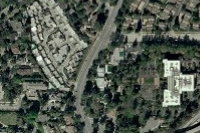

<Item title:"Landsat 8 Views" type:Image Service owner:esri>
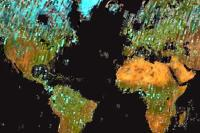

In [142]:
items = gis.content.search("Landsat 8 Views", max_items=2, outside_org=True)
for item in items:
    display(item)

In [143]:
l8 = items[1]

In [144]:
l8.layers

[<ImageLayer url:"http://landsat2.arcgis.com/arcgis/rest/services/Landsat8_Views/ImageServer">]

In [145]:
imgsvr = ImageLayer(l8.url, gis)

In [146]:
imgsvr.properties

{
  "fields": [
    {
      "name": "OBJECTID",
      "domain": null,
      "type": "esriFieldTypeOID",
      "alias": "OBJECTID"
    },
    {
      "name": "Shape",
      "domain": null,
      "type": "esriFieldTypeGeometry",
      "alias": "Shape"
    },
    {
      "name": "Name",
      "domain": null,
      "type": "esriFieldTypeString",
      "length": 200,
      "alias": "Name"
    },
    {
      "name": "MinPS",
      "domain": null,
      "type": "esriFieldTypeDouble",
      "alias": "MinPS"
    },
    {
      "name": "MaxPS",
      "domain": null,
      "type": "esriFieldTypeDouble",
      "alias": "MaxPS"
    },
    {
      "name": "LowPS",
      "domain": null,
      "type": "esriFieldTypeDouble",
      "alias": "LowPS"
    },
    {
      "name": "HighPS",
      "domain": null,
      "type": "esriFieldTypeDouble",
      "alias": "HighPS"
    },
    {
      "name": "Category",
      "domain": {
        "codedValues": [
          {
            "name": "Unknown",
            "c

In [147]:
l8lyr = l8.layers[0]

In [148]:
l8lyr.properties

{
  "fields": [
    {
      "name": "OBJECTID",
      "domain": null,
      "type": "esriFieldTypeOID",
      "alias": "OBJECTID"
    },
    {
      "name": "Shape",
      "domain": null,
      "type": "esriFieldTypeGeometry",
      "alias": "Shape"
    },
    {
      "name": "Name",
      "domain": null,
      "type": "esriFieldTypeString",
      "length": 200,
      "alias": "Name"
    },
    {
      "name": "MinPS",
      "domain": null,
      "type": "esriFieldTypeDouble",
      "alias": "MinPS"
    },
    {
      "name": "MaxPS",
      "domain": null,
      "type": "esriFieldTypeDouble",
      "alias": "MaxPS"
    },
    {
      "name": "LowPS",
      "domain": null,
      "type": "esriFieldTypeDouble",
      "alias": "LowPS"
    },
    {
      "name": "HighPS",
      "domain": null,
      "type": "esriFieldTypeDouble",
      "alias": "HighPS"
    },
    {
      "name": "Category",
      "domain": {
        "codedValues": [
          {
            "name": "Unknown",
            "c

In [149]:
for fn in l8lyr.properties.rasterFunctionInfos:
    print(fn.name)

Agriculture with DRA
Bathymetric with DRA
Color Infrared with DRA
Natural Color with DRA
Short-wave Infrared with DRA
Geology with DRA
Agriculture
Bathymetric
Color Infrared
Geology
Natural Color
Short-wave Infrared
NDVI Colorized
Normalized Difference Moisture Index Colorized
NDVI Raw
NBR Raw
None


In [150]:
l8lyr

<ImageLayer url:"http://landsat2.arcgis.com/arcgis/rest/services/Landsat8_Views/ImageServer">